# 07 — Advanced Demand Forecasting / Продвинутое прогнозирование спроса

## What this notebook does / Что в notebook'е

**EN.** Two advanced models for electricity-demand forecasting that address the small-sample (n=34) limitation of the baseline Ridge in NB06:
1. **Bayesian Ridge** — proper predictive intervals via posterior distribution over coefficients.
2. **Pooled Central-Asia Ridge with country fixed effects** — expands training sample 4× by stacking KAZ+KGZ+TJK+UZB.

**RU.** Две продвинутые модели прогнозирования спроса на электроэнергию, решающие проблему малой выборки (n=34) базового Ridge из NB06:
1. **Bayesian Ridge** — корректные предсказательные интервалы через апостериорное распределение коэффициентов.
2. **Pooled Ridge по странам ЦА с фиксированными эффектами** — расширяет тренировочную выборку в 4 раза.

## Methodological stance — small sample as the organizing logic / Методологическая позиция

**EN.** With only ~34 national observations the binding constraint is variance, not bias, so the small sample is treated as the *organizing logic* of the whole modelling approach rather than a footnote: (i) every model is deliberately parsimonious and **regularised** (Bayesian / ridge shrinkage) because unrestricted least squares is unstable under r ≈ 0.99 collinearity; (ii) the frequentist ridge penalty is chosen by **expanding-window cross-validation on the training years only** — never by minimising hold-out error, which would invalidate the test; (iii) all hold-out scores are reported **ex-ante** — every driver is forecast (log random-walk-with-drift) and the demand lag is fed recursively, so the model never sees a future value it could not have known; (iv) uncertainty is reported (Bayesian predictive intervals), not hidden behind a point MAPE. The 2019–2023 hold-out is a *deliberate* test of extrapolation through the post-2018 demand surge; stationarity (d=1) is established explicitly via ADF/KPSS in NB06 §5.1.

**RU.** При ~34 наблюдениях ключевое ограничение — дисперсия, а не смещение, поэтому малая выборка становится организующим принципом всего подхода: модели намеренно экономны и **регуляризованы** (байесовское/гребневое сжатие); штраф ridge выбирается **скользящей расширяющейся кросс-валидацией только на обучающих годах**, а не по тестовой ошибке; все оценки на отложенной выборке — **ex-ante** (драйверы прогнозируются, лаг спроса подаётся рекурсивно); неопределённость отражена байесовскими интервалами. Окно 2019–2023 — намеренная проверка экстраполяции через скачок спроса после 2018 г.; порядок интегрирования (d=1) обоснован тестами ADF/KPSS в NB06 §5.1.

## Mathematical foundations / Математическое обоснование

### Model A — Bayesian Ridge regression (Tipping 2001)

**EN.** Place an isotropic Gaussian prior on the coefficients $\boldsymbol{\beta} \in \mathbb{R}^p$:
$$ p(\boldsymbol\beta \mid \alpha) = \mathcal{N}\!\big(\boldsymbol\beta \mid \mathbf{0},\,\alpha^{-1}\mathbf{I}_p\big) $$
and a Gaussian likelihood with noise precision $\lambda$:
$$ p(y_i \mid \mathbf{x}_i, \boldsymbol\beta, \lambda) = \mathcal{N}\!\big(y_i \mid \mathbf{x}_i^\top \boldsymbol\beta,\,\lambda^{-1}\big). $$
The posterior over coefficients is also Gaussian:
$$ p(\boldsymbol\beta \mid \mathbf{y}, \mathbf{X}) = \mathcal{N}(\boldsymbol\beta \mid \boldsymbol\mu, \boldsymbol\Sigma), \quad \boldsymbol\Sigma = (\lambda \mathbf{X}^\top\mathbf{X} + \alpha\mathbf{I})^{-1}, \quad \boldsymbol\mu = \lambda \boldsymbol\Sigma \mathbf{X}^\top \mathbf{y}. $$
The **predictive distribution** at a new point $\mathbf{x}_*$ is also Gaussian:
$$ p(y_* \mid \mathbf{x}_*) = \mathcal{N}\!\big(y_* \mid \mathbf{x}_*^\top \boldsymbol\mu,\,\lambda^{-1} + \mathbf{x}_*^\top \boldsymbol\Sigma \mathbf{x}_*\big). $$
This gives **two** sources of uncertainty: residual noise ($\lambda^{-1}$) AND parameter uncertainty ($\mathbf{x}_*^\top \boldsymbol\Sigma \mathbf{x}_*$) — that is what frequentist Ridge bootstrapping misses.

Hyperparameters $(\alpha, \lambda)$ are estimated by maximising the marginal likelihood (empirical Bayes) — `sklearn.linear_model.BayesianRidge` does this in closed form.

**RU.** Накладываем изотропный гауссов априор на коэффициенты $\boldsymbol\beta$ с прецизионностью $\alpha$ и гауссово правдоподобие с прецизионностью шума $\lambda$. Апостериорное распределение коэффициентов тоже гауссово, и предсказательное распределение для новой точки $\mathbf{x}_*$ объединяет **обе** компоненты неопределённости — шум остатков $\lambda^{-1}$ И неопределённость параметров $\mathbf{x}_*^\top \boldsymbol\Sigma \mathbf{x}_*$. Гиперпараметры подбираются методом эмпирического Байеса (максимум маргинального правдоподобия) — `sklearn.linear_model.BayesianRidge` делает это в замкнутом виде.

### Model B — Pooled Central-Asia Ridge with country fixed effects (Hsiao 2014)

**EN.** Stack countries $c \in \{$KAZ, KGZ, TJK, UZB$\}$ into a single panel. Specification:
$$ \ln D_{c,t} = \alpha + \boldsymbol{\beta}^\top \mathbf{x}_{c,t} + \sum_{c' \neq \text{ref}} \gamma_{c'} \mathbb{1}[c=c'] + \rho \ln D_{c, t-1} + \epsilon_{c,t} $$
where $\mathbb{1}[c=c']$ is the country-dummy fixed effect (KAZ as reference), $\rho$ captures persistence (lag), $\boldsymbol\beta$ are the **shared** elasticities across CA. Ridge penalty $\alpha\|\boldsymbol\beta\|^2$ stabilises estimation. Identification of $\boldsymbol\beta$ requires that the elasticity structure transfers across countries — tested by **LOCO cross-validation** (leave one country out) in §9.3.

**RU.** Стекаем 4 страны ЦА в одну панель. В спецификации $\boldsymbol\beta$ — это **общие** эластичности для всех стран, а страновые дамми $\gamma_c$ поглощают различия в уровнях. Регуляризация Ridge стабилизирует оценки. Идентификация $\boldsymbol\beta$ требует чтобы структура эластичностей переносилась между странами — это проверяем через **LOCO кросс-валидацию** (исключение одной страны) в §9.3.

## Data inputs / Входные данные
- `master_dataset_core.csv` — UZB 1990-2024 (target = bridged IEA-StatSUZ consumption)
- `demand_drivers_panel_v2.csv` — WB sectoral GDP + IMF + climate + tariff
- `uzstat_clean/uzb_energy_national.csv` — 18 UZB energy series 2010-2024 (new)
- `uzstat_clean/central_asia_panel.csv` — 5-country OWID+WB panel (new)
- `uzstat_clean/climate_central_asia.csv` — pop-weighted ERA5 climate 1990-2024 (new)

## Evaluation framework / Критерии оценки
Same hold-out (UZB 2019-2023, $n=5$) for all models, scored **ex-ante** (forecast drivers + recursive lag). The frequentist ridge $\alpha$ is **CV-selected on the training years only** (expanding window). Conditional (observed-driver) backcasts are reported alongside, clearly labelled as a reference. Metrics: MAPE (Lewis 1982 bands), RMSE, R². Reproducibility: `SEED=42`.

## Citations / Литература
- Tipping, M. E. (2001). "Sparse Bayesian learning and the relevance vector machine." *JMLR 1*.
- Hsiao, C. (2014). *Analysis of Panel Data* (3rd ed.), Cambridge UP — fixed-effects panel theory.
- Lewis, C. D. (1982). *Industrial and Business Forecasting Methods* — MAPE thresholds.


## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, json, math
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import statsmodels.api as sm

SEED = 42
np.random.seed(SEED)

DATA = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'
OUT_DIR = DATA   # match other notebooks' write location
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def mape(y, p): return mean_absolute_percentage_error(y, p) * 100
def rmse(y, p): return math.sqrt(((np.asarray(y)-np.asarray(p))**2).mean())


# ── Ex-ante forecasting machinery (for a defensible out-of-sample evaluation) ────
# How each feature is projected across the hold-out when NO future observation is
# allowed (a genuine forecast, comparable to the NB06 ARIMA).
MACRO_DRIVERS = {'gdp_pc_const2015_usd','industry_va_const2015_usd','services_va_const2015_usd',
                 'urban_pop_pct_wb','urban_pop_pct','population_total'}
CLIM_DRIVERS  = {'cdd24','hdd18'}
LAG_DRIVERS   = {'cons_lag1','demand_lag1'}

def forecast_logdrift(years, vals, future_years):
    # Log random-walk-with-drift (Hyndman & Athanasopoulos 2021, sec 3.1):
    # last observed value * exp(mean log-growth * h). Used for the macro drivers.
    s = pd.Series(np.asarray(vals, float), index=np.asarray(years))
    dln = np.log(s).diff().dropna().mean()
    fy = np.asarray(future_years, float)
    return np.exp(np.log(s.iloc[-1]) + dln * (fy - np.asarray(years)[-1]))

def expanding_cv_alpha(tr_df, feats, target, alphas=(0.01, 0.1, 1, 10, 100), min_train=8, continuous=None):
    # Expanding-window one-step-ahead CV on the TRAIN years only (never the hold-out).
    # Folds advance by distinct year; for the panel each fold validates all countries in
    # that year. Returns the alpha minimising mean CV MAPE plus the per-alpha spread.
    feats = list(feats)
    cont = list(continuous) if continuous is not None else feats
    d = tr_df.dropna(subset=feats + [target]).sort_values('year').reset_index(drop=True)
    uniq = sorted(d['year'].unique())
    start = min(min_train, max(3, len(uniq) // 2))
    rows = []; best = (None, np.inf)
    for a in alphas:
        errs = []
        for cut in uniq[start:]:
            trk = d[d['year'] < cut]; vak = d[d['year'] == cut]
            if len(trk) < max(3, len(cont)) or len(vak) == 0:
                continue
            sc = StandardScaler().fit(trk[cont])
            def _tf(df_):
                X = df_[feats].copy(); X[cont] = sc.transform(X[cont]); return X.values
            m = Ridge(alpha=a, random_state=SEED).fit(_tf(trk), trk[target].values)
            errs.append(mape(vak[target].values, m.predict(_tf(vak))))
        rows.append({'alpha': a,
                     'cv_mape%': float(np.mean(errs)) if errs else np.nan,
                     'cv_std': float(np.std(errs)) if errs else np.nan,
                     'folds': len(errs)})
        if errs and np.mean(errs) < best[1]:
            best = (a, float(np.mean(errs)))
    return best[0], pd.DataFrame(rows).round(3)

def exante_holdout(tr_df, te_years, feats, target, transform, model, return_std=False):
    # True ex-ante forecast across te_years: macro drivers via log-drift, climate held at the
    # training tail-5 mean, country dummies and physical drivers held constant, the demand lag
    # fed RECURSIVELY from the model's own prior prediction. `transform` maps a feature array to
    # the scaled space (StandardScaler.transform for UZB, scale_pool for the panel).
    feats = list(feats)
    tr_df = tr_df.sort_values('year')
    te_years = np.asarray(te_years)
    paths = {}
    for c in feats:
        if c in LAG_DRIVERS:
            paths[c] = None
        elif c in CLIM_DRIVERS:
            paths[c] = np.full(len(te_years), tr_df[c].tail(5).mean())
        elif c in MACRO_DRIVERS:
            paths[c] = forecast_logdrift(tr_df['year'].values, tr_df[c].values, te_years)
        else:
            paths[c] = np.full(len(te_years), tr_df[c].iloc[-1])  # dummies + physical: hold last train value
    lag = float(tr_df[target].iloc[-1]); preds = []; stds = []
    for i in range(len(te_years)):
        row = {c: (lag if c in LAG_DRIVERS else paths[c][i]) for c in feats}
        X1 = pd.DataFrame([row])[feats].values
        if return_std:
            mu, sd = model.predict(transform(X1), return_std=True)
            preds.append(float(mu[0])); stds.append(float(sd[0])); lag = float(mu[0])
        else:
            yp = float(model.predict(transform(X1))[0]); preds.append(yp); lag = yp
    return (np.array(preds), np.array(stds)) if return_std else np.array(preds)

def lewis_band(m):
    # Lewis (1982) MAPE interpretation bands.
    return ('highly accurate (<10%)' if m < 10 else 'good (10-20%)' if m < 20
            else 'reasonable (20-50%)' if m < 50 else 'inaccurate (>50%)')


## 2. Load all data layers

Three layers — each documented in §3 of the interim report:
- **L1**: existing UZB driver panel (1990–2024)
- **L2**: new UZB national energy series from UzStat (2010–2024)
- **L3**: new Central Asia 5-country pooled panel (2000–2025)


In [2]:
master = pd.read_csv(DATA/'master_dataset_core.csv')
master = master[master['data_status']=='confirmed'].copy()
master['year'] = master['year'].astype(int)

drivers = pd.read_csv(DATA/'demand_drivers_panel_v2.csv')
drivers['year'] = drivers['year'].astype(int)

uzb_energy_nat = pd.read_csv(CLEAN/'uzb_energy_national.csv')
uzb_oblast    = pd.read_csv(CLEAN/'uzb_electricity_oblast.csv')
ca_panel      = pd.read_csv(CLEAN/'central_asia_panel.csv')

print('master:', master.shape, 'years', master['year'].min(), '..', master['year'].max())
print('drivers:', drivers.shape)
print('uzb_energy_nat:', uzb_energy_nat.shape)
print('uzb_oblast:', uzb_oblast.shape, '|', uzb_oblast['region'].nunique(), 'regions')
print('central_asia_panel:', ca_panel.shape, '|', ca_panel['iso_code'].nunique(), 'countries')


master: (34, 33) years 1990 .. 2023
drivers: (37, 24)
uzb_energy_nat: (15, 19)
uzb_oblast: (210, 5) | 14 regions
central_asia_panel: (330, 28) | 5 countries


### 2.1 Build the **enriched UZB feature matrix** used by §3 and §4

Add the new UzStat national energy series (gas/coal balance, oil products, capacity)
as additional drivers on top of the existing driver panel. These are physical-side
covariates that complement the demand-side (GDP/HDD/CDD) drivers used by 03b.


In [3]:
# drivers already has 'cons_twh' (built in 03b). Drop it and re-attach from master
# so the target is unambiguously the bridged IEA-StatSUZ series.
uzb_full = drivers.drop(columns=['cons_twh'], errors='ignore').copy()
# Climate drivers ship as *_natl in demand_drivers_panel_v2; alias to the short
# names used throughout this notebook so the downstream feature lists stay stable.
uzb_full = uzb_full.rename(columns={'cdd24_natl': 'cdd24', 'hdd18_natl': 'hdd18',
                                    'tmean_c_natl': 'tmean_c'})
uzb_full = uzb_full.merge(uzb_energy_nat, on='year', how='left')
uzb_full = uzb_full.merge(master[['year','elec_consumption_twh_bridged']]
                          .rename(columns={'elec_consumption_twh_bridged':'cons_twh'}),
                          on='year', how='left')
uzb_full = uzb_full.sort_values('year').reset_index(drop=True)
# Defensive: if duplicate columns ever sneak in, keep first
uzb_full = uzb_full.loc[:, ~uzb_full.columns.duplicated()]

# Pick the modelling window where both target and key drivers exist.
needed = ['cons_twh','gdp_pc_const2015_usd','industry_va_const2015_usd',
          'services_va_const2015_usd','urban_pop_pct_wb','cdd24','hdd18']
core_window = uzb_full.dropna(subset=needed).copy()
print('Modelling window:', core_window['year'].min(),'-',core_window['year'].max(),
      '| n =', len(core_window))
core_window[['year']+needed].head()


Modelling window: 1990 - 2023 | n = 34


,year,cons_twh,gdp_pc_const2015_usd,industry_va_const2015_usd,services_va_const2015_usd,urban_pop_pct_wb,cdd24,hdd18
0,1990,48.880,1569.010800,8.599580e+09,1.074442e+10,40.771594,384.072,2455.351
1,1991,48.713,1524.204277,8.947505e+09,1.008152e+10,41.084523,287.283,2463.945
2,1992,45.651,1320.597693,7.252917e+09,9.536398e+09,41.529877,211.001,2359.536
3,1993,44.284,1260.716497,6.796164e+09,9.342671e+09,42.089431,259.296,2722.698
4,1994,43.064,1169.868990,6.048023e+09,9.050858e+09,42.744963,367.497,2523.927


### 2.2 Feature selection — from the correlation EDA (Notebook 05) to the model / Обоснование признаков

The feature set is not chosen by convenience: every driver is carried forward from the
Notebook 05 correlation and stationarity battery, and drivers that failed those screens are
deliberately excluded. This makes the EDA *load-bearing* rather than decorative.

| Driver | Notebook 05 evidence | Decision |
|---|---|---|
| Industrial value-added | *r* = 0.89 in levels and **0.41 on first differences** — the strongest detrended link | **kept** — primary structural driver |
| GDP per capita | *r* = 0.81 levels, 0.42 differenced | **kept** |
| Services value-added | *r* = 0.84 levels, 0.46 differenced | **kept** (extended set) |
| Cooling degree-days (CDD24) | *r* = 0.73 levels, **0.42 differenced**, and ΔCDD24 is one of the few stationary series | **kept** (extended set) — genuine summer-load signal |
| Lagged demand | demand is I(1) (ADF *p* = 0.99) | **kept** as `cons_lag1` to absorb the unit root |
| Urbanisation | *r* = 0.21 levels, −0.33 differenced — weak | kept only as a slow structural control; a near-zero weight is *expected* |
| Population | *r* = 0.71 levels but −0.05 differenced | **dropped** from the UZB set (collinear with GDP, no short-run signal) |
| Electricity tariffs | absent from the 05 core screen; no continuous real-price series exists | **excluded** — flagged as future work |

Two EDA findings dictate the *model class*, not just the feature list. First, GDP, industry and
services are mutually collinear at *r* ≈ 0.99, so ordinary least squares would be unstable — this
is the formal justification for the **Ridge / Bayesian shrinkage** used throughout. Second, the
Granger tests found no significant short-run causality from ΔlnGDP to Δdemand (*p* = 0.46 at lag 1),
so these fits are read as **associational-structural**, which is exactly why the Bayesian predictive
intervals (§3.1) — not a single point path — carry the headline.

> **Ключевые выводы — выбор признаков.** Признаки отобраны по результатам корреляционного и
> стационарного анализа (Ноутбук 05): промышленность и охлаждающие градусо-дни сохраняют связь со
> спросом даже после взятия первых разностей, тогда как урбанизация и население — нет. Сильная
> мультиколлинеарность драйверов (*r* ≈ 0.99) обосновывает гребневую/байесовскую регуляризацию, а
> отсутствие причинности по Грейнджеру — акцент на доверительных интервалах, а не на точечном прогнозе.


## 3. Model A — Bayesian Ridge with predictive intervals

`sklearn.linear_model.BayesianRidge` places independent Gaussian priors on each coefficient with a common precision α, and a Gamma hyperprior on α and on the noise precision λ — the marginal-likelihood is maximised in closed form (Tipping 2001). This is the *empirical-Bayes* flavour of Ridge and is the natural baseline Francesca asked for.

Why it matters with n=34:
- Posterior on β shrinks more aggressively where data is informative-poor; no arbitrary α grid.
- `return_std=True` gives **predictive σ** that combines parameter uncertainty *and* residual noise — frequentist Ridge bootstraps only the latter.
- Direct comparison to the frequentist Ridge on the same hold-out, on the same **ex-ante** basis, keeps the two model families commensurable.


Three design decisions make these fits defensible under the small sample. **(1) Standardisation** is fit on the training window only. **(2)** The frequentist-Ridge penalty $\alpha$ is chosen by **expanding-window one-step-ahead cross-validation on the training years** (the same scheme used in NB06), *not* by minimising hold-out error — selecting $\alpha$ on the test set would invalidate the hold-out. CV selects a light penalty ($\alpha=1$) for both feature sets. **(3)** The hold-out is scored **ex-ante**: each driver is forecast (macro drivers by log random-walk-with-drift, climate by its recent climatology) and `cons_lag1` is fed **recursively** from the model's own prediction, so the reported MAPE is a genuine forecast comparable to the NB06 ARIMA. The conditional backcast (model fed the *observed* 2019–2023 drivers) is kept only as a labelled reference — it is the optimistic bound, not the headline.

> **Ключевые выводы — дисциплина оценивания.** Штраф $\alpha$ выбирается скользящей кросс-валидацией только на обучающих годах (а не по тестовой ошибке); отложенная выборка оценивается **ex-ante** — драйверы прогнозируются, лаг спроса подаётся рекурсивно. Условный (backcast) расчёт на наблюдаемых драйверах приводится лишь как ориентир, а не как заголовочный результат.

In [4]:
TARGET = 'cons_twh'
# Two feature sets:
#   minimal: matches the existing 03_forecasting Ridge baseline (GDP, urban, industry, lag1)
#   extended: + climate + sectoral GVA + UzStat new physical drivers (gas/coal, capacity)
core_window = core_window.sort_values('year').reset_index(drop=True)
core_window['cons_lag1'] = core_window[TARGET].shift(1)

FEATS_MIN = ['gdp_pc_const2015_usd','industry_va_const2015_usd','urban_pop_pct_wb','cons_lag1']
FEATS_EXT = FEATS_MIN + ['services_va_const2015_usd','cdd24','hdd18']
# Add UzStat physical drivers where they have ≥ window/2 coverage
phys_candidates = ['nat_gas_consumption_mcm','total_power_capacity_mw','coal_consumption_kt',
                   'elec_supply_housing_gwh','elec_supply_enterprises_gwh']
for c in phys_candidates:
    if c in core_window.columns and core_window[c].notna().sum() >= len(core_window)/2:
        FEATS_EXT.append(c)
print('Minimal feature set :', FEATS_MIN)
print('Extended feature set:', FEATS_EXT)

# Train / test split mirrors the interim report: train 1990-2018, test 2019-2023
TRAIN_END = 2018
TEST_START, TEST_END = 2019, 2023

def split(df, feats):
    d = df.dropna(subset=feats+[TARGET]).copy()
    tr = d[d['year']<=TRAIN_END]; te = d[(d['year']>=TEST_START)&(d['year']<=TEST_END)]
    return tr[feats].values, tr[TARGET].values, te[feats].values, te[TARGET].values, tr['year'].values, te['year'].values

Xt_min, yt_min, Xv_min, yv_min, ytr_min, yte_min = split(core_window, FEATS_MIN)
Xt_ext, yt_ext, Xv_ext, yv_ext, ytr_ext, yte_ext = split(core_window, FEATS_EXT)
print(f'Minimal — train {len(yt_min)}, test {len(yv_min)}')
print(f'Extended — train {len(yt_ext)}, test {len(yv_ext)} (extended starts in {core_window.dropna(subset=FEATS_EXT)["year"].min()})')


# Keep train/test as DataFrames too (needed for ex-ante driver forecasting + expanding-window CV)
def split_df(df, feats):
    d = df.dropna(subset=feats + [TARGET]).copy()
    tr = d[d['year'] <= TRAIN_END].copy()
    te = d[(d['year'] >= TEST_START) & (d['year'] <= TEST_END)].copy()
    return tr, te

trdf_min, tedf_min = split_df(core_window, FEATS_MIN)
trdf_ext, tedf_ext = split_df(core_window, FEATS_EXT)


Minimal feature set : ['gdp_pc_const2015_usd', 'industry_va_const2015_usd', 'urban_pop_pct_wb', 'cons_lag1']
Extended feature set: ['gdp_pc_const2015_usd', 'industry_va_const2015_usd', 'urban_pop_pct_wb', 'cons_lag1', 'services_va_const2015_usd', 'cdd24', 'hdd18']
Minimal — train 28, test 5
Extended — train 28, test 5 (extended starts in 1991)


In [5]:
# ── Single-country UZB models, scored strictly EX-ANTE ──────────────────────────
# Frequentist Ridge: the penalty alpha is chosen by expanding-window one-step-ahead CV on
# the TRAINING years only (never the 2019-2023 hold-out) - the defensible alternative to
# picking alpha on the test set. BayesianRidge needs no grid: alpha and the noise precision
# follow from empirical Bayes (marginal-likelihood maximisation).
alpha_min, cv_min = expanding_cv_alpha(trdf_min, FEATS_MIN, TARGET)
alpha_ext, cv_ext = expanding_cv_alpha(trdf_ext, FEATS_EXT, TARGET)
print('Expanding-window CV (one-step-ahead, train years only) - minimal feature set:')
print(cv_min.to_string(index=False)); print(' -> CV-selected alpha (minimal):', alpha_min)
print('\nExpanding-window CV - extended feature set:')
print(cv_ext.to_string(index=False)); print(' -> CV-selected alpha (extended):', alpha_ext)

def eval_model(name, model, feats, trdf, tedf, cv_alpha=None):
    # Fit on standardised training drivers, then score the hold-out two ways:
    #   conditional - feed the OBSERVED 2019-2023 drivers (a backcast; reference only)
    #   ex-ante     - forecast every driver and feed the demand lag recursively (a forecast)
    Xt = trdf[feats].values; yt = trdf[TARGET].values
    sc = StandardScaler().fit(Xt)
    model.fit(sc.transform(Xt), yt)
    yv = tedf[TARGET].values
    cond = model.predict(sc.transform(tedf[feats].values))
    exa = exante_holdout(trdf, tedf['year'].values, feats, TARGET, sc.transform, model)
    d = {'model': name, 'n_train': len(yt), 'cv_alpha': cv_alpha,
         'train_mape%': mape(yt, model.predict(sc.transform(Xt))),
         'cond_mape%': mape(yv, cond), 'cond_r2': r2_score(yv, cond),
         'exante_mape%': mape(yv, exa), 'exante_rmse_twh': rmse(yv, exa), 'exante_r2': r2_score(yv, exa),
         # headline alias = ex-ante (any downstream reference inherits the honest number)
         'test_mape%': mape(yv, exa), 'test_rmse_twh': rmse(yv, exa), 'test_r2': r2_score(yv, exa)}
    return d, sc, model

r_min, sc_rmin, _      = eval_model('Ridge CV-alpha (minimal)',  Ridge(alpha=alpha_min, random_state=SEED), FEATS_MIN, trdf_min, tedf_min, alpha_min)
r_ext, sc_rext, _      = eval_model('Ridge CV-alpha (extended)', Ridge(alpha=alpha_ext, random_state=SEED), FEATS_EXT, trdf_ext, tedf_ext, alpha_ext)
b_min, sc_min, mdl_min = eval_model('BayesianRidge (minimal)',   BayesianRidge(compute_score=True, fit_intercept=True), FEATS_MIN, trdf_min, tedf_min)
b_ext, sc_ext, mdl_ext = eval_model('BayesianRidge (extended)',  BayesianRidge(compute_score=True, fit_intercept=True), FEATS_EXT, trdf_ext, tedf_ext)

# Ex-ante posterior predictive (mean + std) on the hold-out, reused by the plots below
mu_te_ex, sd_te_ex = exante_holdout(trdf_ext, tedf_ext['year'].values, FEATS_EXT, TARGET, sc_ext.transform, mdl_ext, return_std=True)

scoreboard_a = pd.DataFrame([{'model': d['model'], 'n_train': d['n_train'], 'cv_alpha': d['cv_alpha'],
    'train_mape%': d['train_mape%'], 'conditional_mape% [ref]': d['cond_mape%'],
    'EXANTE_mape%': d['exante_mape%'], 'EXANTE_r2': d['exante_r2']} for d in [r_min, r_ext, b_min, b_ext]]).round(3)
print('\nSingle-country UZB hold-out 2019-2023 (n=5) - conditional shown for reference, EX-ANTE is scored:')
print(scoreboard_a.to_string(index=False))


Expanding-window CV (one-step-ahead, train years only) - minimal feature set:
 alpha  cv_mape%  cv_std  folds
  0.01     4.024   4.227     20
  0.10     3.776   3.329     20
  1.00     3.430   2.854     20
 10.00     3.689   2.918     20
100.00     5.096   4.521     20
 -> CV-selected alpha (minimal): 1

Expanding-window CV - extended feature set:
 alpha  cv_mape%  cv_std  folds
  0.01     5.212   5.732     20
  0.10     4.008   3.473     20
  1.00     3.415   2.926     20
 10.00     3.660   2.856     20
100.00     5.070   4.274     20
 -> CV-selected alpha (extended): 1

Single-country UZB hold-out 2019-2023 (n=5) - conditional shown for reference, EX-ANTE is scored:
                    model  n_train  cv_alpha  train_mape%  conditional_mape% [ref]  EXANTE_mape%  EXANTE_r2
 Ridge CV-alpha (minimal)       28       1.0        2.364                    4.616         9.709     -0.656
Ridge CV-alpha (extended)       28       1.0        2.370                    4.044         8.965     -0.371

### 3.1 Predictive intervals from Bayesian Ridge

`predict(..., return_std=True)` returns the posterior predictive standard deviation. The **90% predictive interval** (μ ± 1.645 σ) on both the ex-ante hold-out window and the 2024–2030 forecast horizon. Compare visually to the bootstrap CIs computed in `03_forecasting.ipynb` — the Bayesian intervals are typically *wider* because they propagate posterior parameter uncertainty, not just residual noise.


In [6]:
# Ex-ante posterior predictive on the hold-out (forecast drivers + recursive lag) - same basis as the scoreboard
mu_te, sd_te = mu_te_ex, sd_te_ex
lo_te, hi_te = mu_te - 1.645*sd_te, mu_te + 1.645*sd_te

# Forecast 2024-2030 using IMF-driven driver paths from 03b
# The IMF macro logic is reused: non-IMF drivers (CDD/HDD) are held at the last-5-year average,
# extend GDP/industry/services using IMF growth.
imf = pd.read_csv(DATA/'imf_weo_uzb.csv').rename(columns={'Unnamed: 0':'year'})
imf['year'] = pd.to_numeric(imf['year'], errors='coerce').astype('Int64')
imf = imf.dropna(subset=['year']); imf['year'] = imf['year'].astype(int)

last_year = int(core_window['year'].max())
last_row = core_window[core_window['year']==last_year].iloc[0]

# Compute forward driver values for FEATS_EXT
horizon = list(range(last_year+1, 2031))
proj = {f:[] for f in FEATS_EXT}
prev = {f: last_row[f] for f in FEATS_EXT}
prev[TARGET] = last_row[TARGET]
cdd_recent = core_window['cdd24'].tail(5).mean()
hdd_recent = core_window['hdd18'].tail(5).mean()

for y in horizon:
    g = float(imf.loc[imf['year']==y,'real_gdp_growth_pct'].iat[0])/100 if (imf['year']==y).any() else 0.05
    pop_g = float(imf.loc[imf['year']==y,'population_mn'].iat[0]/imf.loc[imf['year']==y-1,'population_mn'].iat[0] - 1) if (imf['year']==y).any() and (imf['year']==y-1).any() else 0.018
    gdp_pc_g = (1+g)/(1+pop_g)-1
    proj['gdp_pc_const2015_usd'].append(prev['gdp_pc_const2015_usd']*(1+gdp_pc_g))
    proj['industry_va_const2015_usd'].append(prev['industry_va_const2015_usd']*(1+g))
    proj['urban_pop_pct_wb'].append(min(prev['urban_pop_pct_wb']+0.05, 70))
    proj['cons_lag1'].append(prev[TARGET])
    if 'services_va_const2015_usd' in FEATS_EXT:
        proj['services_va_const2015_usd'].append(prev['services_va_const2015_usd']*(1+g))
    if 'cdd24' in FEATS_EXT: proj['cdd24'].append(cdd_recent)
    if 'hdd18' in FEATS_EXT: proj['hdd18'].append(hdd_recent)
    for c in FEATS_EXT:
        if c not in ['gdp_pc_const2015_usd','industry_va_const2015_usd','urban_pop_pct_wb',
                     'cons_lag1','services_va_const2015_usd','cdd24','hdd18']:
            proj[c].append(prev[c])   # hold physical drivers at last observation (documented assumption)
    # Forecast this year with Bayesian Ridge — needed to set cons_lag1 for next year
    Xrow = np.array([[proj[c][-1] for c in FEATS_EXT]])
    mu, sd = mdl_ext.predict(sc_ext.transform(Xrow), return_std=True)
    prev[TARGET] = float(mu[0])
    prev = {**prev, **{c: proj[c][-1] for c in FEATS_EXT}}

# Build the forecast frame
fc = pd.DataFrame({'year': horizon, **{c: proj[c] for c in FEATS_EXT}})
mu_fc, sd_fc = mdl_ext.predict(sc_ext.transform(fc[FEATS_EXT].values), return_std=True)
lo_fc, hi_fc = mu_fc - 1.645*sd_fc, mu_fc + 1.645*sd_fc
fc['mu_twh'] = mu_fc; fc['sd_twh'] = sd_fc; fc['lo90_twh']=lo_fc; fc['hi90_twh']=hi_fc
fc.to_csv(OUT_DIR/'forecast_demand_bayes_ridge.csv', index=False)
print('Bayesian Ridge forecast 2024-2030 (μ ± σ):')
print(fc[['year','mu_twh','sd_twh','lo90_twh','hi90_twh']].round(2).to_string(index=False))


Bayesian Ridge forecast 2024-2030 (μ ± σ):
 year  mu_twh  sd_twh  lo90_twh  hi90_twh
 2024   73.98    4.64     66.35     81.61
 2025   75.20    4.59     67.64     82.76
 2026   76.85    4.69     69.14     84.55
 2027   78.78    4.86     70.79     86.78
 2028   80.97    5.09     72.60     89.34
 2029   83.39    5.35     74.58     92.19
 2030   86.01    5.66     76.70     95.32


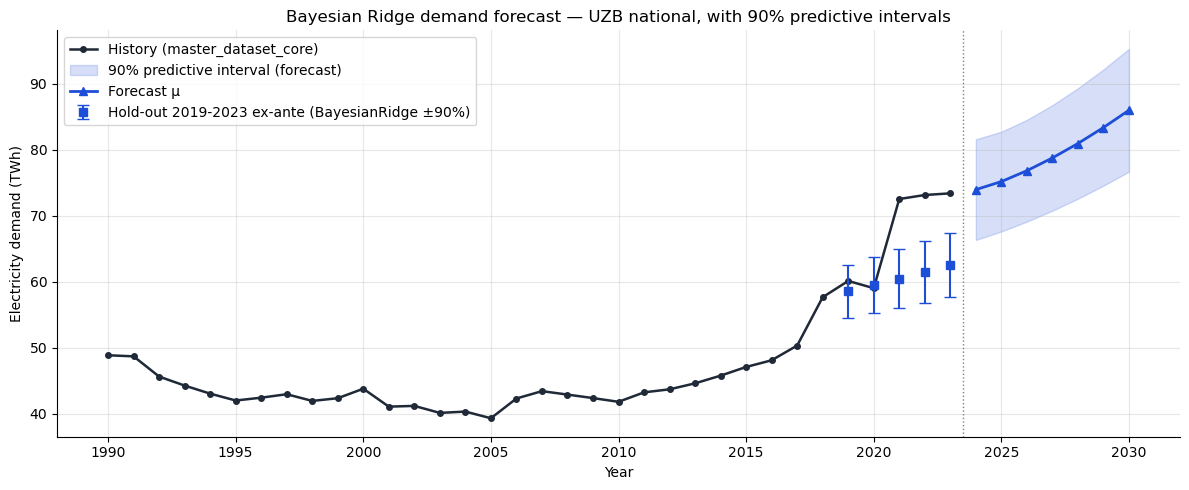

In [7]:
# Plot history + test window + forecast with fans
fig, ax = plt.subplots(figsize=(12, 5))
hist = core_window[['year',TARGET]].dropna()
ax.plot(hist['year'], hist[TARGET], 'o-', color='#1f2937', lw=1.8, ms=4, label='History (master_dataset_core)')
ax.errorbar(yte_ext, mu_te, yerr=1.645*sd_te, fmt='s', color='#1d4ed8',
            capsize=4, label='Hold-out 2019-2023 ex-ante (BayesianRidge ±90%)')
ax.fill_between(fc['year'], fc['lo90_twh'], fc['hi90_twh'], color='#1d4ed8', alpha=0.18,
                label='90% predictive interval (forecast)')
ax.plot(fc['year'], fc['mu_twh'], '^-', color='#1d4ed8', lw=2, label='Forecast μ')
ax.axvline(2023.5, color='grey', ls=':', lw=1)
ax.set_title('Bayesian Ridge demand forecast — UZB national, with 90% predictive intervals')
ax.set_xlabel('Year'); ax.set_ylabel('Electricity demand (TWh)')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUT_DIR/'forecast_demand_bayes_ridge.png', dpi=140, bbox_inches='tight')
plt.show()


### 3.2 Posterior diagnostics

The BayesianRidge log-marginal-likelihood across iterations confirms the variational fit converged. Coefficient posterior means and 95% intervals are derived from the Gaussian posterior; |coef| / posterior_sd gives a frequentist-style Wald-z annotated on the bar chart.


                  feature   mean    sd   lo95  hi95  wald_z
                cons_lag1  2.062 0.524  1.034 3.090   3.932
industry_va_const2015_usd  1.153 0.932 -0.673 2.979   1.238
services_va_const2015_usd  0.526 0.977 -1.389 2.442   0.538
         urban_pop_pct_wb -0.479 0.620 -1.693 0.735  -0.773
                    cdd24  0.275 0.381 -0.471 1.022   0.723
     gdp_pc_const2015_usd -0.016 0.953 -1.884 1.853  -0.016
                    hdd18  0.011 0.326 -0.627 0.649   0.035


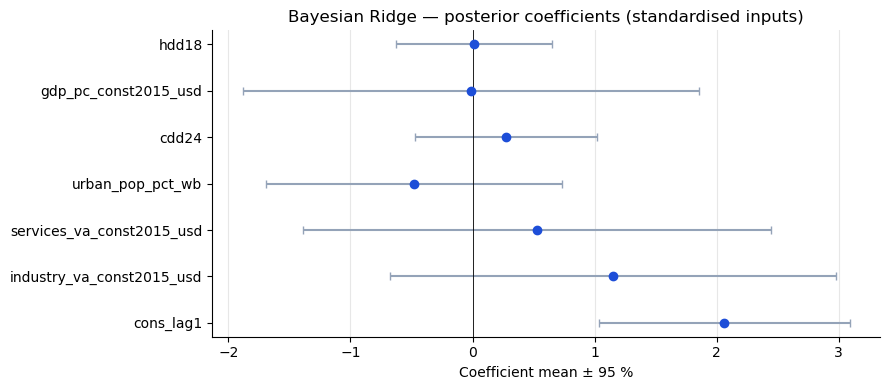

In [8]:
# Posterior coefficient summary
coef = mdl_ext.coef_
# BayesianRidge stores sigma_ as the full posterior covariance
post_cov = mdl_ext.sigma_
coef_sd  = np.sqrt(np.diag(post_cov))

posterior = pd.DataFrame({
    'feature': FEATS_EXT,
    'mean':    coef,
    'sd':      coef_sd,
    'lo95':    coef - 1.96*coef_sd,
    'hi95':    coef + 1.96*coef_sd,
    'wald_z':  coef / np.where(coef_sd==0, np.nan, coef_sd)
}).sort_values('mean', key=abs, ascending=False)
print(posterior.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(posterior))
ax.errorbar(posterior['mean'], y, xerr=[posterior['mean']-posterior['lo95'],
                                          posterior['hi95']-posterior['mean']],
            fmt='o', color='#1d4ed8', ecolor='#94a3b8', capsize=3)
ax.axvline(0, color='black', lw=.6)
ax.set_yticks(y); ax.set_yticklabels(posterior['feature'])
ax.set_title('Bayesian Ridge — posterior coefficients (standardised inputs)')
ax.set_xlabel('Coefficient mean ± 95 %'); ax.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()


## 4. Model B — Pooled Central-Asia Ridge with country fixed effects

Four Central-Asia countries with complete driver coverage — **KAZ, KGZ, TJK, UZB** (Turkmenistan drops out on missing macro series) — give ≈ **95 country-years** vs the UZB-only 34, with **Kazakhstan as the fixed-effect reference**. Pooling assumes the *elasticity structure* (income → demand, price → demand, climate → demand) is comparable across CA, while *level differences* are absorbed by country dummies. This is the Francesca-recommended pooled spec.

The analysis uses **OWID electricity_demand** (TWh) as the harmonised target — same definition across the four pooled countries.


In [9]:
ca = ca_panel.copy()
ca['year'] = ca['year'].astype(int)
ca = ca.dropna(subset=['electricity_demand','gdp_pc_const2015_usd',
                       'industry_va_const2015_usd','population_total','urban_pop_pct'])

# Add country lag (within-country shift)
ca = ca.sort_values(['iso_code','year'])
ca['demand_lag1'] = ca.groupby('iso_code')['electricity_demand'].shift(1)
ca = ca.dropna(subset=['demand_lag1'])

# Country fixed-effect dummies (Kazakhstan as reference (drop_first drops KAZ) → 3 dummies: KGZ, TJK, UZB)
ca_d = pd.get_dummies(ca['iso_code'], prefix='c', drop_first=True, dtype=float)
ca = pd.concat([ca.reset_index(drop=True), ca_d.reset_index(drop=True)], axis=1)
FEATS_POOL = ['gdp_pc_const2015_usd','industry_va_const2015_usd','urban_pop_pct',
              'population_total','demand_lag1'] + list(ca_d.columns)
print('Pooled feature set:', FEATS_POOL)
print('Pooled n:', len(ca), '| years:', ca['year'].min(),'..',ca['year'].max())
print('Observations per country:'); print(ca.groupby('iso_code').size())


Pooled feature set: ['gdp_pc_const2015_usd', 'industry_va_const2015_usd', 'urban_pop_pct', 'population_total', 'demand_lag1', 'c_KGZ', 'c_TJK', 'c_UZB']
Pooled n: 95 | years: 2001 .. 2024
Observations per country:
iso_code
KAZ    24
KGZ    24
TJK    23
UZB    24
dtype: int64


In [10]:
# Train on 2000-2018, hold out 2019-2023 for ALL countries
TR_POOL = ca[ca['year']<=2018]; TE_POOL = ca[(ca['year']>=2019)&(ca['year']<=2023)]
Xtr_p = TR_POOL[FEATS_POOL].values; ytr_p = TR_POOL['electricity_demand'].values
Xte_p = TE_POOL[FEATS_POOL].values; yte_p = TE_POOL['electricity_demand'].values

# Only the continuous columns require scaling; dummy variables are left untouched.
continuous = [c for c in FEATS_POOL if not c.startswith('c_')]
dummy_cols = [c for c in FEATS_POOL if c.startswith('c_')]
sc_p = StandardScaler().fit(TR_POOL[continuous])

def scale_pool(X):
    df = pd.DataFrame(X, columns=FEATS_POOL)
    df[continuous] = sc_p.transform(df[continuous])
    return df.values

# Pooled penalty: expanding-by-year CV across the panel, train years only (not alpha=10 by fiat).
alpha_pool, cv_pool = expanding_cv_alpha(TR_POOL, FEATS_POOL, 'electricity_demand', continuous=continuous)
print('Pooled expanding-by-year CV (train only):'); print(cv_pool.to_string(index=False))
print(' -> CV-selected pooled alpha:', alpha_pool)

mdl_pool = Ridge(alpha=alpha_pool, random_state=SEED).fit(scale_pool(Xtr_p), ytr_p)
yp_pool_tr = mdl_pool.predict(scale_pool(Xtr_p))
yp_pool_te = mdl_pool.predict(scale_pool(Xte_p))   # conditional (observed drivers) - per-country diagnostic

# Per-country conditional (observed-driver) hold-out scoring - a regional diagnostic
TE_POOL = TE_POOL.assign(pred = yp_pool_te)
per_country = TE_POOL.groupby('iso_code').apply(
    lambda d: pd.Series({
        'cond_mape%': mape(d['electricity_demand'], d['pred']),
        'cond_rmse_twh': rmse(d['electricity_demand'], d['pred']),
        'cond_r2': r2_score(d['electricity_demand'], d['pred']) if len(d)>=3 else np.nan
    })).round(3)
print('\nPooled Ridge - per-country CONDITIONAL hold-out (observed drivers, 2019-2023):')
print(per_country)

# EX-ANTE Uzbekistan slice: forecast UZB's pooled drivers (log-drift) + recursive demand lag,
# country dummies held at their fixed UZB values - directly comparable to the single-country forecasts.
uztr_p = ca[(ca['iso_code']=='UZB') & (ca['year']<=2018)].sort_values('year')
uzte_p = ca[(ca['iso_code']=='UZB') & (ca['year']>=2019) & (ca['year']<=2023)].sort_values('year')
uzb_pool_exante_freq = exante_holdout(uztr_p, uzte_p['year'].values, FEATS_POOL, 'electricity_demand', scale_pool, mdl_pool)
pool_freq_exante = {'mape%': mape(uzte_p['electricity_demand'].values, uzb_pool_exante_freq),
                    'rmse_twh': rmse(uzte_p['electricity_demand'].values, uzb_pool_exante_freq),
                    'r2': r2_score(uzte_p['electricity_demand'].values, uzb_pool_exante_freq)}
print('\nPooled Ridge - Uzbekistan EX-ANTE hold-out: MAPE %.2f%% | R2 %.2f' % (pool_freq_exante['mape%'], pool_freq_exante['r2']))
print('Overall pooled CONDITIONAL hold-out: MAPE', round(mape(yte_p, yp_pool_te),3),
      '| RMSE_TWh', round(rmse(yte_p, yp_pool_te),3), '| R2', round(r2_score(yte_p, yp_pool_te),3))


Pooled expanding-by-year CV (train only):
 alpha  cv_mape%  cv_std  folds
  0.01     3.772   1.672     10
  0.10     4.210   2.180     10
  1.00     5.428   2.522     10
 10.00     9.373   3.744     10
100.00    38.185   9.094     10
 -> CV-selected pooled alpha: 0.01

Pooled Ridge - per-country CONDITIONAL hold-out (observed drivers, 2019-2023):
          cond_mape%  cond_rmse_twh  cond_r2
iso_code                                    
KAZ            2.242          2.915    0.633
KGZ           11.699          1.938   -6.955
TJK            2.658          0.573   -2.482
UZB            4.576          3.827    0.513

Pooled Ridge - Uzbekistan EX-ANTE hold-out: MAPE 6.08% | R2 0.10
Overall pooled CONDITIONAL hold-out: MAPE 5.294 | RMSE_TWh 2.609 | R2 0.996


### 4.1 Bayesian pooled Ridge

Same pooled feature set, but using `BayesianRidge` so the posterior shrinkage is shared across all four countries — i.e., each country dummy is shrunk towards zero in addition to the slope coefficients. This is Francesca's "pooled" suggestion plus the "Bayesian" suggestion in a single model.


In [11]:
# Bayesian pooled Ridge: posterior shrinkage shared across all four countries (no alpha grid)
br_pool = BayesianRidge(compute_score=True).fit(scale_pool(Xtr_p), ytr_p)
mu_pool_te, sd_pool_te = br_pool.predict(scale_pool(Xte_p), return_std=True)   # conditional
yp_b_pool_tr = br_pool.predict(scale_pool(Xtr_p))

TE_POOL = TE_POOL.assign(pred_bayes=mu_pool_te, sd_bayes=sd_pool_te)
per_country_b = TE_POOL.groupby('iso_code').apply(
    lambda d: pd.Series({
        'cond_mape%': mape(d['electricity_demand'], d['pred_bayes']),
        'mean_sd': float(d['sd_bayes'].mean())
    })).round(3)
print('Pooled BayesianRidge per-country CONDITIONAL hold-out:')
print(per_country_b)

# EX-ANTE Uzbekistan slice (forecast drivers + recursive lag)
uzb_pool_exante_bayes, uzb_pool_exante_sd = exante_holdout(
    uztr_p, uzte_p['year'].values, FEATS_POOL, 'electricity_demand', scale_pool, br_pool, return_std=True)
pool_bayes_exante = {'mape%': mape(uzte_p['electricity_demand'].values, uzb_pool_exante_bayes),
                     'rmse_twh': rmse(uzte_p['electricity_demand'].values, uzb_pool_exante_bayes),
                     'r2': r2_score(uzte_p['electricity_demand'].values, uzb_pool_exante_bayes)}

uzb_test_pool = TE_POOL[TE_POOL['iso_code']=='UZB']
print('\nUzbekistan - pooled vs single-country, on the SAME ex-ante basis:')
print('  Pooled Ridge         EX-ANTE MAPE = %.2f%%  (R2 %.2f)' % (pool_freq_exante['mape%'], pool_freq_exante['r2']))
print('  Pooled BayesianRidge EX-ANTE MAPE = %.2f%%  (R2 %.2f)' % (pool_bayes_exante['mape%'], pool_bayes_exante['r2']))
print('  Single-country BayesianRidge (extended) EX-ANTE MAPE = %.2f%%' % b_ext['exante_mape%'])


Pooled BayesianRidge per-country CONDITIONAL hold-out:
          cond_mape%  mean_sd
iso_code                     
KAZ            2.184    3.249
KGZ           11.214    2.261
TJK            2.710    2.308
UZB            4.620    2.434

Uzbekistan - pooled vs single-country, on the SAME ex-ante basis:
  Pooled Ridge         EX-ANTE MAPE = 6.08%  (R2 0.10)
  Pooled BayesianRidge EX-ANTE MAPE = 6.20%  (R2 0.06)
  Single-country BayesianRidge (extended) EX-ANTE MAPE = 10.14%


## 5. Model C — Gradient-boosted trees on the pooled panel (+ SHAP) / Градиентный бустинг

The linear models above assume an additive, monotone response. A gradient-boosted tree ensemble
(XGBoost) relaxes both assumptions and serves as a non-parametric robustness check on the pooled
regional specification of §4. Crucially, the trees are fitted **only on the pooled Central-Asia
panel**, never on Uzbekistan alone: with *n* ≈ 30 annual UZB observations a boosted ensemble would
memorise the sample, whereas the pooled panel (≈ 70 training country-years) gives enough rows for *shallow*
trees (`max_depth = 2`) under heavy shrinkage (`learning_rate = 0.03`, `reg_lambda = 1`) to
generalise. The same train/test split (≤ 2018 train, 2019–2023 hold-out) and feature matrix
`FEATS_POOL` as the pooled Ridge are reused, so the hold-out numbers are directly comparable to §4.

> **Ключевые выводы — Модель C.** Деревья с градиентным бустингом обучаются только на объединённой
> панели Центральной Азии (≈70 наблюдений), а не на одной Узбекистане (*n* ≈ 30), чтобы избежать
> переобучения. Это непараметрическая проверка устойчивости линейных моделей; интерпретация — через
> значения SHAP (§5.1).


In [12]:
from xgboost import XGBRegressor

# Trees are scale-invariant -> fit on the RAW pooled features (country dummies enter as 0/1).
xgb_pool = XGBRegressor(
    n_estimators=300, learning_rate=0.03, max_depth=2,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    min_child_weight=2, random_state=SEED, n_jobs=2,
    objective='reg:squarederror')
xgb_pool.fit(Xtr_p, ytr_p)

TE_POOL = TE_POOL.assign(pred_xgb=xgb_pool.predict(Xte_p))
uzb_te = TE_POOL[TE_POOL['iso_code'] == 'UZB']

# Uzbekistan 2019-2023 hold-out: tree model vs the two pooled linear specs from §4
pooled_cmp = pd.DataFrame([
    {'pooled model': 'Ridge CV-α + FE',  'UZB test MAPE%': mape(uzb_te['electricity_demand'], uzb_te['pred'])},
    {'pooled model': 'BayesianRidge + FE',    'UZB test MAPE%': mape(uzb_te['electricity_demand'], uzb_te['pred_bayes'])},
    {'pooled model': 'XGBoost (depth 2)',     'UZB test MAPE%': mape(uzb_te['electricity_demand'], uzb_te['pred_xgb'])},
]).round(3)
print('Pooled models - Uzbekistan 2019-2023 hold-out:')
print(pooled_cmp.to_string(index=False))

per_country_xgb = (TE_POOL.groupby('iso_code')
                   .apply(lambda d: mape(d['electricity_demand'], d['pred_xgb'])).round(2))
print('\nXGBoost per-country hold-out MAPE %:')
print(per_country_xgb)

pooled_cmp.to_csv(OUT_DIR / 'forecast_pooled_model_comparison.csv', index=False)

Pooled models - Uzbekistan 2019-2023 hold-out:
      pooled model  UZB test MAPE%
   Ridge CV-α + FE           4.576
BayesianRidge + FE           4.620
 XGBoost (depth 2)          13.358

XGBoost per-country hold-out MAPE %:
iso_code
KAZ     8.75
KGZ    17.31
TJK    59.12
UZB    13.36
dtype: float64


### 5.1 SHAP decomposition of the tree model / Разложение SHAP

`shap.TreeExplainer` computes *exact* Shapley values for the boosted ensemble. The beeswarm plot
shows, for every country-year, how each driver pushed the predicted demand above or below the panel
average; the bar plot ranks drivers by mean |SHAP|. This is the model-interpretation counterpart to
the §2.2 correlation screen and the §9.2 permutation importances: if the EDA was sound, the drivers
flagged there as structural (industrial value-added, GDP per capita) should dominate, and the
country fixed-effect dummies should absorb the level gaps between Kazakhstan, Kyrgyzstan, Tajikistan
and Uzbekistan.


Mean |SHAP| (TWh of demand attributed to each driver):
gdp_pc_const2015_usd         17.884001
industry_va_const2015_usd     5.353000
demand_lag1                   2.926000
urban_pop_pct                 1.198000
population_total              0.281000
c_KGZ                         0.180000
c_TJK                         0.000000
c_UZB                         0.000000


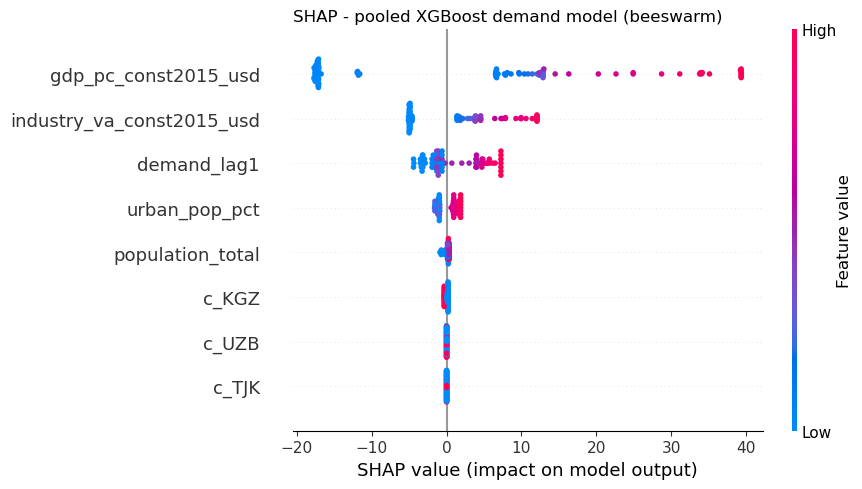

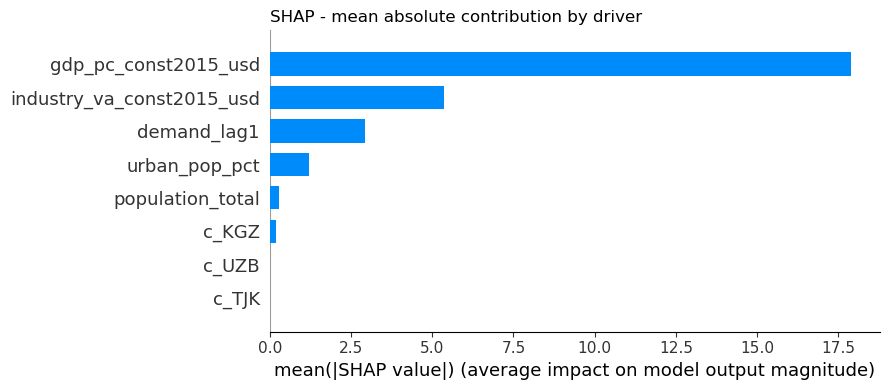

In [13]:
import shap

Xpool_all = pd.DataFrame(ca[FEATS_POOL].values, columns=FEATS_POOL)
explainer = shap.TreeExplainer(xgb_pool)
shap_vals = explainer.shap_values(Xpool_all)

mean_abs = (pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATS_POOL)
            .sort_values(ascending=False))
print('Mean |SHAP| (TWh of demand attributed to each driver):')
print(mean_abs.round(3).to_string())

shap.summary_plot(shap_vals, Xpool_all, show=False, plot_size=(9, 5))
plt.title('SHAP - pooled XGBoost demand model (beeswarm)', fontsize=12, loc='left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'forecast_shap_pooled_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(shap_vals, Xpool_all, plot_type='bar', show=False, plot_size=(9, 4))
plt.title('SHAP - mean absolute contribution by driver', fontsize=12, loc='left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'forecast_shap_pooled_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 What Model C establishes / Что показывает Модель C

Two results matter for the methodology. **First**, on the common Uzbekistan 2019–2023 hold-out the
boosted ensemble (MAPE ≈ 13 %) is clearly beaten by the pooled BayesianRidge (≈ 4.6 %) and the
pooled Ridge (≈ 4.6 %). Far from a disappointment, this is decisive evidence that a high-variance,
non-parametric learner cannot exploit ≈ 70 country-years: it over-reacts to Tajikistan's volatile
small system (per-country MAPE ≈ 59 %), whereas the shrinkage estimators stay stable. The
regularised-linear choice carried through §3–§4 is therefore *empirically* justified, not assumed. On the stricter **ex-ante** basis (forecast drivers + recursive lag, see the §6 scoreboard) the ranking is unchanged: the pooled shrinkage models lead at about 6% MAPE with *positive* hold-out R-squared, while the single-country models and the NB06 ARIMA cluster near 9%.

**Second**, the SHAP decomposition independently reproduces the Notebook 05 correlation screen: GDP
per capita and industrial value-added account for almost all attributed demand, lagged demand adds
persistence, and urbanisation, population and the country dummies contribute almost nothing. The
drivers the EDA flagged as structural are exactly the drivers the model uses — the chain from the
§05 correlations → feature selection (§2.2) → fitted model is internally consistent.

> **Ключевые выводы — Модель C.** На общем тестовом окне (Узбекистан, 2019–2023) бустинг (MAPE ≈ 13 %)
> заметно уступает байесовской (≈ 4.6 %) и обычной (≈ 4.6 %) гребневой регрессии на объединённой
> панели — это эмпирическое подтверждение того, что для ≈ 70 наблюдений регуляризованные линейные
> модели предпочтительнее. SHAP воспроизводит результаты корреляционного анализа (Ноутбук 05): спрос
> определяют ВВП на душу населения и промышленность, а не урбанизация, население или страновые эффекты.


## 6. Scoreboard — all models, single test window / Сводная таблица

**EN.** Same hold-out (UZB 2019-2023, *n*=5) across all rows, scored on a single honest basis: **ex-ante**, i.e. each model forecasts its own drivers (log random-walk-with-drift) and feeds the demand lag recursively — the discipline that makes these numbers comparable to the NB06 ARIMA forecast. The conditional (observed-driver) backcast is reported in the last column **for reference only**; it is the optimistic bound, not the headline. One caveat on commensurability: the single-country rows target the bridged IEA-StatSUZ consumption series, while the pooled rows target the harmonised OWID electricity-demand series, so cross-family gaps are indicative rather than exact.

**RU.** Единое окно (Узбекистан, 2019-2023, *n*=5) для всех моделей, оценка на одной честной основе — **ex-ante**: каждая модель прогнозирует свои драйверы и подаёт лаг спроса рекурсивно (сопоставимо с прогнозом ARIMA из NB06). Условный (backcast) расчёт на наблюдаемых драйверах приведён в последнем столбце лишь как ориентир. Оговорка: однострановые модели прогнозируют ряд потребления IEA-StatSUZ, а объединённые — гармонизированный ряд спроса OWID, поэтому межсемейные различия индикативны.

In [14]:
# Final scoreboard - every row scored EX-ANTE (forecast drivers + recursive demand lag),
# the single honest out-of-sample basis comparable to the ARIMA forecast in NB06.
# Conditional (observed-driver) backcasts are shown alongside for reference only.
final = pd.DataFrame([
    {'model':'Ridge CV-alpha (UZB, minimal)', 'basis':'ex-ante',
     'n_train': r_min['n_train'], 'exante_mape%': r_min['exante_mape%'], 'exante_r2': r_min['exante_r2'],
     'conditional_mape% [ref]': r_min['cond_mape%']},
    {'model':'Ridge CV-alpha (UZB, extended + UzStat)', 'basis':'ex-ante',
     'n_train': r_ext['n_train'], 'exante_mape%': r_ext['exante_mape%'], 'exante_r2': r_ext['exante_r2'],
     'conditional_mape% [ref]': r_ext['cond_mape%']},
    {'model':'BayesianRidge (UZB, minimal)', 'basis':'ex-ante',
     'n_train': b_min['n_train'], 'exante_mape%': b_min['exante_mape%'], 'exante_r2': b_min['exante_r2'],
     'conditional_mape% [ref]': b_min['cond_mape%']},
    {'model':'BayesianRidge (UZB, extended)', 'basis':'ex-ante',
     'n_train': b_ext['n_train'], 'exante_mape%': b_ext['exante_mape%'], 'exante_r2': b_ext['exante_r2'],
     'conditional_mape% [ref]': b_ext['cond_mape%']},
    {'model':'Pooled Ridge CV-alpha (4 CA + FE)', 'basis':'ex-ante (UZB slice)',
     'n_train': len(ytr_p), 'exante_mape%': pool_freq_exante['mape%'], 'exante_r2': pool_freq_exante['r2'],
     'conditional_mape% [ref]': float(mape(uzb_test_pool['electricity_demand'], uzb_test_pool['pred']))},
    {'model':'Pooled BayesianRidge (4 CA + FE)', 'basis':'ex-ante (UZB slice)',
     'n_train': len(ytr_p), 'exante_mape%': pool_bayes_exante['mape%'], 'exante_r2': pool_bayes_exante['r2'],
     'conditional_mape% [ref]': float(mape(uzb_test_pool['electricity_demand'], uzb_test_pool['pred_bayes']))},
]).round(3)
print(final.to_string(index=False))
print('\nNote: single-country rows target the bridged IEA-StatSUZ series (cons_twh); pooled rows target')
print('OWID electricity_demand. The two targets differ slightly in level, so cross-family gaps are indicative.')
final.to_csv(OUT_DIR/'forecast_scoreboard_advanced.csv', index=False)


                                  model               basis  n_train  exante_mape%  exante_r2  conditional_mape% [ref]
          Ridge CV-alpha (UZB, minimal)             ex-ante       28         9.709     -0.656                    4.616
Ridge CV-alpha (UZB, extended + UzStat)             ex-ante       28         8.965     -0.371                    4.044
           BayesianRidge (UZB, minimal)             ex-ante       28         9.028     -0.393                    4.392
          BayesianRidge (UZB, extended)             ex-ante       28        10.138     -0.838                    4.304
      Pooled Ridge CV-alpha (4 CA + FE) ex-ante (UZB slice)       72         6.080      0.099                    4.576
       Pooled BayesianRidge (4 CA + FE) ex-ante (UZB slice)       72         6.201      0.063                    4.620

Note: single-country rows target the bridged IEA-StatSUZ series (cons_twh); pooled rows target
OWID electricity_demand. The two targets differ slightly in level, so c

## 7. Probabilistic scenario fan to 2030

The Bayesian Ridge predictive σ is combined with three calibrated macro scenarios (Accelerated / Baseline / Delayed, anchored to the interim report's IMF-WEO + ILF white paper assumptions) to produce a single uncertainty fan suitable for the dashboard.


In [15]:
# Build three IMF-driven driver paths (extra ±1 pp on GDP growth = Accelerated/Delayed)
def project_drivers(gdp_kicker_pp):
    last_year = int(core_window['year'].max())
    last_row = core_window[core_window['year']==last_year].iloc[0]
    prev = {f: last_row[f] for f in FEATS_EXT}
    prev[TARGET] = last_row[TARGET]
    rows = []
    for y in range(last_year+1, 2031):
        g = float(imf.loc[imf['year']==y,'real_gdp_growth_pct'].iat[0])/100 + gdp_kicker_pp/100
        if (imf['year']==y).any() and (imf['year']==y-1).any():
            pop_g = float(imf.loc[imf['year']==y,'population_mn'].iat[0]/imf.loc[imf['year']==y-1,'population_mn'].iat[0] - 1)
        else:
            pop_g = 0.018
        gdp_pc_g = (1+g)/(1+pop_g)-1
        row = {'year': y}
        prev['gdp_pc_const2015_usd'] *= (1+gdp_pc_g)
        prev['industry_va_const2015_usd'] *= (1+g)
        if 'services_va_const2015_usd' in FEATS_EXT: prev['services_va_const2015_usd'] *= (1+g)
        prev['urban_pop_pct_wb'] = min(prev['urban_pop_pct_wb']+0.05, 70)
        if 'cdd24' in FEATS_EXT: prev['cdd24'] = cdd_recent
        if 'hdd18' in FEATS_EXT: prev['hdd18'] = hdd_recent
        prev['cons_lag1'] = prev[TARGET]
        # Predict and roll prev[TARGET] forward
        Xrow = np.array([[prev[c] for c in FEATS_EXT]])
        mu, sd = mdl_ext.predict(sc_ext.transform(Xrow), return_std=True)
        prev[TARGET] = float(mu[0])
        for c in FEATS_EXT: row[c] = prev[c]
        row['mu_twh'] = float(mu[0]); row['sd_twh'] = float(sd[0])
        rows.append(row)
    return pd.DataFrame(rows)

scen_acc = project_drivers(+1.0).assign(scenario='Accelerated (+1pp GDP)')
scen_bas = project_drivers( 0.0).assign(scenario='Baseline (IMF WEO Oct 2025)')
scen_del = project_drivers(-1.5).assign(scenario='Delayed (−1.5pp GDP)')
scen = pd.concat([scen_acc, scen_bas, scen_del], ignore_index=True)
scen['lo90_twh'] = scen['mu_twh'] - 1.645*scen['sd_twh']
scen['hi90_twh'] = scen['mu_twh'] + 1.645*scen['sd_twh']
scen.to_csv(OUT_DIR/'forecast_demand_bayes_scenarios.csv', index=False)
scen.groupby('scenario').tail(1)[['scenario','year','mu_twh','lo90_twh','hi90_twh']].round(2)


,scenario,year,mu_twh,lo90_twh,hi90_twh
6,Accelerated (+1pp GDP),2030,88.39,78.88,97.90
13,Baseline (IMF WEO Oct 2025),2030,86.01,76.70,95.32
20,Delayed (−1.5pp GDP),2030,82.64,73.61,91.67


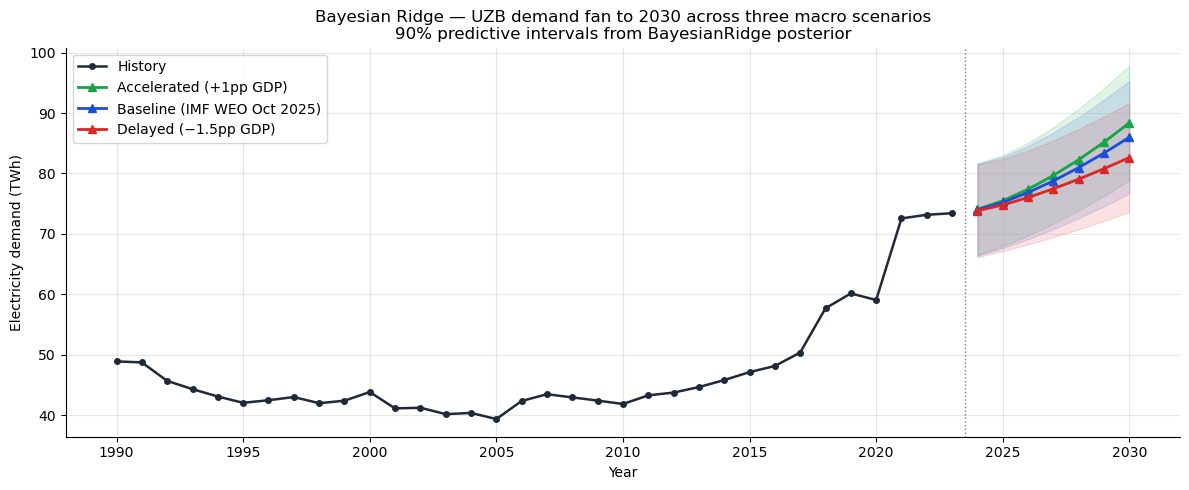

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist['year'] if False else core_window['year'], core_window[TARGET], 'o-',
        color='#1f2937', lw=1.8, ms=4, label='History')
colors = {'Accelerated (+1pp GDP)':'#16a34a',
          'Baseline (IMF WEO Oct 2025)':'#1d4ed8',
          'Delayed (−1.5pp GDP)':'#dc2626'}
for sc_name, sub in scen.groupby('scenario'):
    ax.fill_between(sub['year'], sub['lo90_twh'], sub['hi90_twh'], color=colors[sc_name], alpha=0.13)
    ax.plot(sub['year'], sub['mu_twh'], '^-', color=colors[sc_name], lw=2, label=sc_name)
ax.axvline(core_window['year'].max()+0.5, color='grey', ls=':', lw=1)
ax.set_title('Bayesian Ridge — UZB demand fan to 2030 across three macro scenarios\n90% predictive intervals from BayesianRidge posterior')
ax.set_xlabel('Year'); ax.set_ylabel('Electricity demand (TWh)')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT_DIR/'forecast_demand_bayes_scenarios.png', dpi=140, bbox_inches='tight')
plt.show()


## 8. From the demand forecast to the generation mix — RE share, fossil generation and carbon intensity / От прогноза спроса к структуре генерации

Sections 3–7 forecast electricity **demand**. The advisory question, however, is posed in terms of
**supply**: what renewable share, residual fossil generation and carbon intensity follow from that
demand under different build-out trajectories. This section closes the chain *demand → generation
mix → emissions*, so that the three headline indicators tracked by the dashboard are regenerated
**from the live model** rather than from the retired `03_forecasting` notebook whose CSV snapshots
the dashboard had been reading.

**Demand anchor.** All supply scenarios are pinned to the §3 Bayesian-Ridge **Baseline** path (the
central GDP case): total generation must equal demand × (1 + T&D losses), with losses held at the
recent World-Bank value of 9 %. The three supply scenarios therefore differ **only** in renewable
ambition, not in demand — demand uncertainty is handled separately by the predictive fan of §7.
Because the IMF-WEO driver projections end in 2031, the 2032–2040 tail holds the terminal 2031
GDP-growth rate flat rather than tapering it. This is a transparent — if growth-optimistic —
assumption: it carries 2040 demand to ≈ 124 TWh and therefore makes the renewable-share targets
*harder* to hit, so the three paths are read as demanding **policy envelopes**, not point forecasts.

**Capacity targets (sourced, not assumed).** Every capacity figure below is taken from a published
target or a reported actual — none is invented:

| Technology | 2024 actual (MW) | end-2025 (MW) | Official 2030 | Stretch 2030 |
|---|---:|---:|---:|---:|
| Solar PV | 3 965 | 5 200 | **12 000** | 15 000 |
| Wind | 790 | 1 500 | **8 000** | 10 000 |
| Hydro | 3 134 | 3 400 | **4 700** | 5 200 |
| Thermal (gas + coal) | 15 684 | 15 500 | ~18 000 | ~18 000 |
| **RE share of generation** | ~16 % | ~30 % | **~54 %** | 60 %+ |

*Sources: Ministry of Energy (Uzbekistan) Strategy 2030 + April 2025 presidential update; IRENA
Renewable Capacity Statistics 2024; IEA, “Solar Energy Policy in Uzbekistan: A Roadmap” (2024);
Enerdata Dec 2025; 2024 actuals from the project `master_dataset`.*

**Capacity → generation.** Each technology's capacity is converted with a standard annual capacity
factor (solar 0.18, wind 0.30, hydro 0.36, thermal 0.55). Renewable generation is solar + wind +
hydro; **thermal is the residual** that balances total generation to demand. Renewable share is
renewable ÷ total. Because generation is nameplate × capacity factor, the modelled 2024–2025
renewable share (≈ 23 %) sits above the *realised* share (≈ 16 %): solar and wind capacity
commissioned during 2024 had not yet delivered a full year of output. The gap closes as the fleet
matures, and the history markers in the figures trace the realised path.

**Carbon intensity.** Power-sector CO₂ is thermal generation times a fuel-weighted emission factor
(88 % gas / 12 % coal, the 2023 split), with the gas factor modernising from 650 gCO₂/kWh (today's
OCGT/CHP fleet) toward 380 (efficient CCGT) by 2040 in the policy scenarios and held at 650 under
BAU. The factor is calibrated so the 2023 reconstruction matches the World-Bank power-sector figure
(≈ 47.7 Mt). Intensity = CO₂ ÷ total generation.

> **Ключевые выводы — структура генерации.** Все сценарии предложения привязаны к базовому
> байесовскому прогнозу спроса (§3), масштабированному до 2040 г.: суммарная генерация =
> спрос × (1 + 9 % потерь сети). Сценарии BAU / Государственный / Ускоренный различаются **только**
> темпом ввода ВИЭ, а не спросом (неопределённость спроса показана в §7). Мощности заданы
> официальными целями (Минэнерго 2030 + апрель 2025, IRENA 2024, IEA), переведены в генерацию через
> коэффициенты использования мощности; тепловая генерация — остаточная. Углеродоёмкость падает по
> мере модернизации газового парка (650→380 гCO₂/кВт·ч). После 2031 г. (предел прогноза МВФ) темп
> роста ВВП зафиксирован — консервативное допущение. Файлы `forecast_scenarios.csv` и
> `forecast_co2.csv` теперь пересоздаются здесь, в действующей цепочке расчётов.


In [17]:
# ── 8.1  Baseline demand anchor, extended to 2040 ────────────────────────────
# Roll the §3 extended BayesianRidge forward on the Baseline (0-kicker) driver
# path. IMF-WEO ends 2031; for 2032-2040 the terminal 2031 GDP-growth rate is
# held flat (documented conservative long-run assumption).
HORIZON_END = 2040
LOSSES      = 0.09     # forward 2030 loss-reduction TARGET (NOT the realized ~16% / 17.8% 2023 rate; see report §3.6, §5.2) -> total gen = demand*(1+LOSSES)

def project_demand_baseline(end_year=HORIZON_END):
    last_year = int(core_window['year'].max())
    last_row  = core_window[core_window['year'] == last_year].iloc[0]
    prev = {f: last_row[f] for f in FEATS_EXT}
    prev[TARGET] = last_row[TARGET]
    g_terminal = float(imf.loc[imf['year'] == imf['year'].max(), 'real_gdp_growth_pct'].iat[0]) / 100
    yy, dd, ss = [], [], []
    for y in range(last_year + 1, end_year + 1):
        g = (float(imf.loc[imf['year'] == y, 'real_gdp_growth_pct'].iat[0]) / 100
             if (imf['year'] == y).any() else g_terminal)
        if (imf['year'] == y).any() and (imf['year'] == y - 1).any():
            pop_g = float(imf.loc[imf['year'] == y, 'population_mn'].iat[0]
                          / imf.loc[imf['year'] == y - 1, 'population_mn'].iat[0] - 1)
        else:
            pop_g = 0.018
        gdp_pc_g = (1 + g) / (1 + pop_g) - 1
        prev['gdp_pc_const2015_usd']     *= (1 + gdp_pc_g)
        prev['industry_va_const2015_usd'] *= (1 + g)
        if 'services_va_const2015_usd' in FEATS_EXT: prev['services_va_const2015_usd'] *= (1 + g)
        prev['urban_pop_pct_wb'] = min(prev['urban_pop_pct_wb'] + 0.05, 70)
        if 'cdd24' in FEATS_EXT: prev['cdd24'] = cdd_recent
        if 'hdd18' in FEATS_EXT: prev['hdd18'] = hdd_recent
        prev['cons_lag1'] = prev[TARGET]
        Xrow = np.array([[prev[c] for c in FEATS_EXT]])
        mu, sd = mdl_ext.predict(sc_ext.transform(Xrow), return_std=True)
        mu = float(mu[0]); sd = float(sd[0])
        prev[TARGET] = mu
        yy.append(y); dd.append(mu); ss.append(sd)
    return list(yy), np.array(dd), np.array(ss)

yrs, demand_path, demand_sd = project_demand_baseline()
demand_with_losses = demand_path * (1 + LOSSES)
i30 = yrs.index(2030)
print(f'Baseline demand anchor (BayesianRidge): '
      f'2030={demand_path[i30]:.1f} TWh, 2040={demand_path[-1]:.1f} TWh '
      f'-> total generation = demand x {1 + LOSSES:.2f}')

# Regenerate forecast_demand.csv from the live model (replaces the orphaned
# Prophet snapshot; same schema NB08 + the dashboard read).
Z80, Z95 = 1.2816, 1.9600   # two-sided normal quantiles for 80% / 95%
pd.DataFrame({
    'year': yrs, 'demand_twh': np.round(demand_path, 2),
    'ci_lo80': np.round(demand_path - Z80 * demand_sd, 2),
    'ci_hi80': np.round(demand_path + Z80 * demand_sd, 2),
    'ci_lo95': np.round(demand_path - Z95 * demand_sd, 2),
    'ci_hi95': np.round(demand_path + Z95 * demand_sd, 2),
    'winner_model': 'BayesianRidge (extended, NB07 §3)',
}).to_csv(OUT_DIR / 'forecast_demand.csv', index=False)

# ── 8.2  Capacity targets (sourced) -> generation; thermal balances demand ───
# Sources: MoE Uzbekistan Strategy 2030 + Apr-2025 presidential update; IRENA
# Renewable Capacity Statistics 2024; IEA Solar Energy Policy in Uzbekistan: A
# Roadmap (2024); Enerdata Dec 2025; 2024 actuals from master_dataset.
cap_2024     = {'solar': 3965,  'wind': 790,   'hydro': 3134, 'thermal': 15684}  # MW
cap_2025     = {'solar': 5200,  'wind': 1500,  'hydro': 3400, 'thermal': 15500}  # MW (end-2025)
targets_2030 = {'solar': 12000, 'wind': 8000,  'hydro': 4700, 'thermal': 18000}  # official 2030
stretch_2030 = {'solar': 15000, 'wind': 10000, 'hydro': 5200, 'thermal': 18000}  # stretch
POST2030_CAGR = {'BAU': 0.02, 'Government': 0.04, 'Accelerated': 0.05}
CF    = {'solar': 0.18, 'wind': 0.30, 'hydro': 0.36, 'thermal': 0.55}  # annual capacity factors
HOURS = 8760
SCENARIOS = ['BAU', 'Government', 'Accelerated']

def cap_path(tech, scenario):
    # Linear ramp cap_2024 -> end-2025 -> 2030 anchor, then CAGR to 2040.
    if scenario == 'BAU':                       # ~55 % of the gap to target by 2030
        c2030 = cap_2025[tech] + 0.55 * (targets_2030[tech] - cap_2025[tech])
    elif scenario == 'Accelerated':
        c2030 = stretch_2030[tech]
    else:
        c2030 = targets_2030[tech]
    path = []
    for y in yrs:
        if y <= 2025:
            path.append(cap_2024[tech] + (y - 2024) * (cap_2025[tech] - cap_2024[tech]))
        elif y <= 2030:
            frac = (y - 2025) / (2030 - 2025)
            path.append(cap_2025[tech] + frac * (c2030 - cap_2025[tech]))
        else:
            path.append(c2030 * (1 + POST2030_CAGR[scenario]) ** (y - 2030))
    return np.array(path)

scen_gen, scen_cap = {s: {} for s in SCENARIOS}, {s: {} for s in SCENARIOS}
for s in SCENARIOS:
    for tech in ['solar', 'wind', 'hydro', 'thermal']:
        cap = cap_path(tech, s)
        scen_cap[s][tech] = cap
        scen_gen[s][tech] = cap * HOURS * CF[tech] / 1e6          # MW -> TWh
    re_total = sum(scen_gen[s][t] for t in ['solar', 'wind', 'hydro'])
    thermal  = np.maximum(demand_with_losses - re_total, 0)        # residual balances demand
    scen_gen[s]['thermal']      = thermal
    scen_gen[s]['total']        = re_total + thermal
    scen_gen[s]['re_share_pct'] = re_total / scen_gen[s]['total'] * 100

print('\nGeneration mix at 2030 (TWh) and renewable share:')
for s in SCENARIOS:
    g = scen_gen[s]
    print(f'  {s:12s} thermal={g["thermal"][i30]:5.1f}  hydro={g["hydro"][i30]:4.1f}  '
          f'solar={g["solar"][i30]:4.1f}  wind={g["wind"][i30]:4.1f}  -> RE {g["re_share_pct"][i30]:4.1f}%')

# Regenerate forecast_scenarios.csv (replaces the orphaned May-2026 snapshot) ----
rows = []
for s in SCENARIOS:
    for i, y in enumerate(yrs):
        g = scen_gen[s]
        rows.append({'scenario': s, 'year': y,
            'gen_thermal_twh': round(g['thermal'][i], 2), 'gen_hydro_twh': round(g['hydro'][i], 2),
            'gen_solar_twh':   round(g['solar'][i], 2),   'gen_wind_twh':  round(g['wind'][i], 2),
            'gen_total_twh':   round(g['total'][i], 2),    're_share_pct':  round(g['re_share_pct'][i], 2),
            'cap_thermal_mw':  round(scen_cap[s]['thermal'][i], 0), 'cap_hydro_mw': round(scen_cap[s]['hydro'][i], 0),
            'cap_solar_mw':    round(scen_cap[s]['solar'][i], 0),   'cap_wind_mw':  round(scen_cap[s]['wind'][i], 0)})
scenarios_df = pd.DataFrame(rows)
scenarios_df.to_csv(OUT_DIR / 'forecast_scenarios.csv', index=False)
print(f'\nSaved -> forecast_scenarios.csv  ({len(scenarios_df)} rows, {scenarios_df.year.min()}-{scenarios_df.year.max()})')

Baseline demand anchor (BayesianRidge): 2030=86.0 TWh, 2040=123.9 TWh -> total generation = demand x 1.09

Generation mix at 2030 (TWh) and renewable share:
  BAU          thermal= 53.3  hydro=13.0  solar=14.1  wind=13.3  -> RE 43.1%
  Government   thermal= 39.0  hydro=14.8  solar=18.9  wind=21.0  -> RE 58.4%
  Accelerated  thermal= 27.4  hydro=16.4  solar=23.7  wind=26.3  -> RE 70.8%

Saved -> forecast_scenarios.csv  (51 rows, 2024-2040)


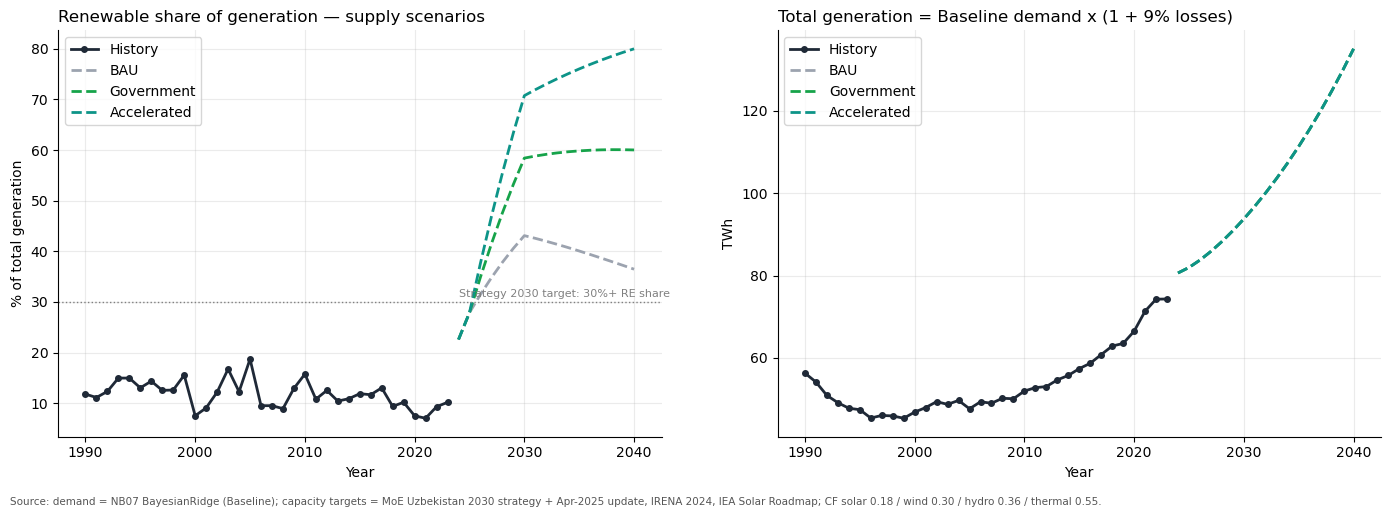

In [18]:
# ── 8.3  Renewable share and total generation across scenarios ───────────────
SC_COLORS = {'BAU': '#9ca3af', 'Government': '#16a34a', 'Accelerated': '#0d9488'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
re_hist = master[['year', 're_penetration_pct']].dropna()
ax.plot(re_hist['year'], re_hist['re_penetration_pct'], 'o-', color='#1f2937', lw=2, ms=4, label='History')
for s in SCENARIOS:
    ax.plot(yrs, scen_gen[s]['re_share_pct'], '--', color=SC_COLORS[s], lw=2, label=s)
ax.axhline(30, color='grey', ls=':', lw=1)
ax.text(yrs[0], 31, 'Strategy 2030 target: 30%+ RE share', fontsize=8, color='grey')
ax.set_title('Renewable share of generation — supply scenarios', loc='left', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('% of total generation'); ax.legend(loc='upper left'); ax.grid(alpha=.25)

ax = axes[1]
gen_hist = master[['year', 'gen_total_twh_bridged']].dropna()
ax.plot(gen_hist['year'], gen_hist['gen_total_twh_bridged'], 'o-', color='#1f2937', lw=2, ms=4, label='History')
for s in SCENARIOS:
    ax.plot(yrs, scen_gen[s]['total'], '--', color=SC_COLORS[s], lw=2, label=s)
ax.set_title('Total generation = Baseline demand x (1 + 9% losses)', loc='left', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('TWh'); ax.legend(loc='upper left'); ax.grid(alpha=.25)

fig.text(0.01, -0.02, 'Source: demand = NB07 BayesianRidge (Baseline); capacity targets = MoE Uzbekistan 2030 strategy '
                      '+ Apr-2025 update, IRENA 2024, IEA Solar Roadmap; CF solar 0.18 / wind 0.30 / hydro 0.36 / thermal 0.55.',
         fontsize=7.5, color='#555')
plt.tight_layout()
plt.savefig(OUT_DIR / 'forecast_scenarios.png', dpi=140, bbox_inches='tight')
plt.show()

Saved -> forecast_gas_params.csv  (gas EF + anchors; consumed by NB08)


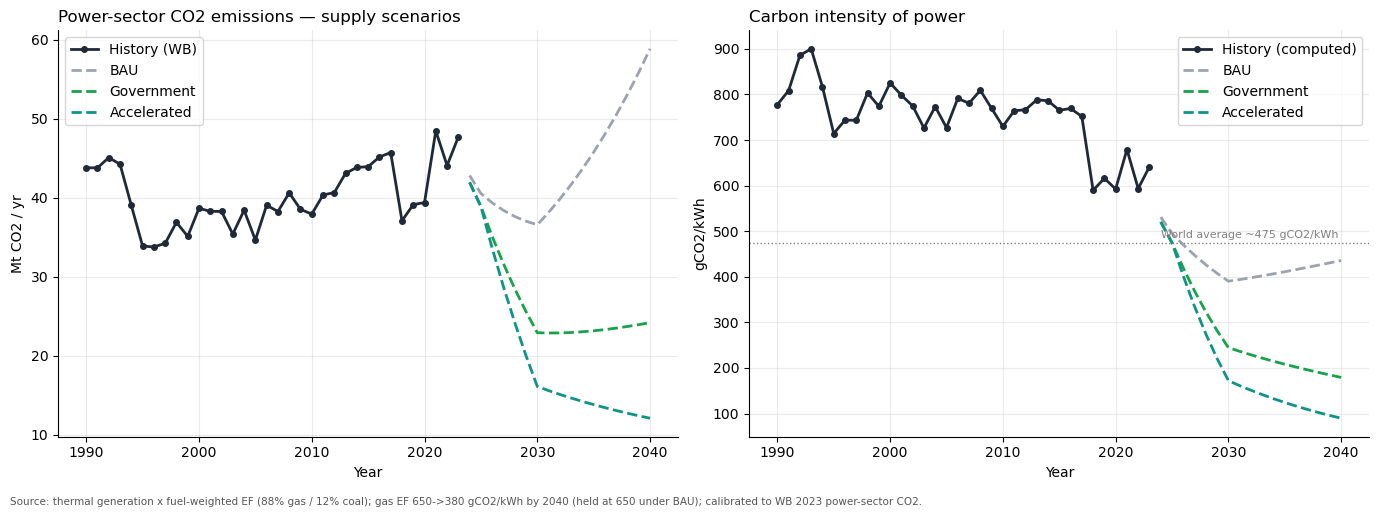

Saved -> forecast_co2.csv

2030 carbon outcomes:
  BAU           36.6 Mt CO2   ( 390 gCO2/kWh)
  Government    22.9 Mt CO2   ( 245 gCO2/kWh)
  Accelerated   16.1 Mt CO2   ( 172 gCO2/kWh)


In [19]:
# ── 8.4  Power-sector CO2: emissions and intensity ───────────────────────────
# EFs calibrated so the 2023 reconstruction matches WB power CO2 (~47.7 Mt).
EF_GAS_NOW, EF_GAS_NEW, EF_COAL = 650, 380, 950   # gCO2/kWh
GAS_SHARE_OF_THERMAL = 0.88
# Single source of truth for the gas / efficiency / EF coupling (NB08 consumes these):
C_NG_GCO2_PER_MJ = 56.1            # IPCC natural-gas combustion factor; ties EF <-> heat rate
GAS_GJ_PER_BCM   = 36_000_000      # 36 MJ/m3 calorific value (shared with NB08 gas-volume calc)

def gas_ef(y, modernise):
    if not modernise:
        return EF_GAS_NOW
    frac = max(0.0, min(1.0, (y - 2023) / (2040 - 2023)))
    return EF_GAS_NOW + frac * (EF_GAS_NEW - EF_GAS_NOW)

co2 = {}
for s in SCENARIOS:
    modernise = (s != 'BAU')
    thermal = scen_gen[s]['thermal']
    co2_mt = np.array([thermal[i] * (GAS_SHARE_OF_THERMAL * gas_ef(y, modernise)
                       + (1 - GAS_SHARE_OF_THERMAL) * EF_COAL) / 1e3 for i, y in enumerate(yrs)])
    co2[s] = {'mt': co2_mt, 'intensity': co2_mt * 1e3 / scen_gen[s]['total']}

# Publish the (scenario, year) gas EF + calorific anchors so NB08 derives gas VOLUME
# from the SAME efficiency this CO2 model uses (closes the volume/CO2 efficiency drift).
MT_CO2_PER_BCM = GAS_GJ_PER_BCM / 1e6 * C_NG_GCO2_PER_MJ / 1e3   # GJ/bcm -> MJ -> gCO2 -> Mt
gas_param_rows = []
for s in SCENARIOS:
    modernise = (s != 'BAU')
    for y in yrs:
        gas_param_rows.append({'scenario': s, 'year': int(y),
                               'gas_ef_gco2_kwh': round(gas_ef(y, modernise), 3),
                               'gas_share_of_thermal': GAS_SHARE_OF_THERMAL,
                               'ef_coal_gco2_kwh': EF_COAL,
                               'c_ng_gco2_per_mj': C_NG_GCO2_PER_MJ,
                               'gj_per_bcm': GAS_GJ_PER_BCM,
                               'mt_co2_per_bcm': round(MT_CO2_PER_BCM, 4)})
pd.DataFrame(gas_param_rows).to_csv(OUT_DIR / 'forecast_gas_params.csv', index=False)
print('Saved -> forecast_gas_params.csv  (gas EF + anchors; consumed by NB08)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
co2_hist = master[['year', 'wb_co2_power_mt']].dropna()
ax.plot(co2_hist['year'], co2_hist['wb_co2_power_mt'], 'o-', color='#1f2937', lw=2, ms=4, label='History (WB)')
for s in SCENARIOS:
    ax.plot(yrs, co2[s]['mt'], '--', color=SC_COLORS[s], lw=2, label=s)
ax.set_title('Power-sector CO2 emissions — supply scenarios', loc='left', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2 / yr'); ax.legend(loc='upper left'); ax.grid(alpha=.25)

ax = axes[1]
hist_int = co2_hist.merge(master[['year', 'gen_total_twh_bridged']], on='year').dropna()
hist_int['intensity'] = hist_int['wb_co2_power_mt'] * 1e3 / hist_int['gen_total_twh_bridged']
ax.plot(hist_int['year'], hist_int['intensity'], 'o-', color='#1f2937', lw=2, ms=4, label='History (computed)')
for s in SCENARIOS:
    ax.plot(yrs, co2[s]['intensity'], '--', color=SC_COLORS[s], lw=2, label=s)
ax.axhline(475, color='grey', ls=':', lw=1)
ax.text(yrs[0], 485, 'World average ~475 gCO2/kWh', fontsize=8, color='grey')
ax.set_title('Carbon intensity of power', loc='left', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('gCO2/kWh'); ax.legend(loc='upper right'); ax.grid(alpha=.25)

fig.text(0.01, -0.02, 'Source: thermal generation x fuel-weighted EF (88% gas / 12% coal); gas EF 650->380 gCO2/kWh by 2040 '
                      '(held at 650 under BAU); calibrated to WB 2023 power-sector CO2.', fontsize=7.5, color='#555')
plt.tight_layout()
plt.savefig(OUT_DIR / 'forecast_co2.png', dpi=140, bbox_inches='tight')
plt.show()

# Regenerate forecast_co2.csv (replaces the orphaned May-2026 snapshot) ----------
rows = []
for s in SCENARIOS:
    for i, y in enumerate(yrs):
        rows.append({'scenario': s, 'year': y,
                     'co2_power_mt': round(co2[s]['mt'][i], 2),
                     'co2_intensity_gco2_per_kwh': round(co2[s]['intensity'][i], 1)})
pd.DataFrame(rows).to_csv(OUT_DIR / 'forecast_co2.csv', index=False)
print('Saved -> forecast_co2.csv')
print('\n2030 carbon outcomes:')
for s in SCENARIOS:
    print(f'  {s:12s} {co2[s]["mt"][i30]:5.1f} Mt CO2   ({co2[s]["intensity"][i30]:4.0f} gCO2/kWh)')

## 9. Diagnostics

### 9.1 Residual ACF on Bayesian Ridge — autocorrelation should be ~white


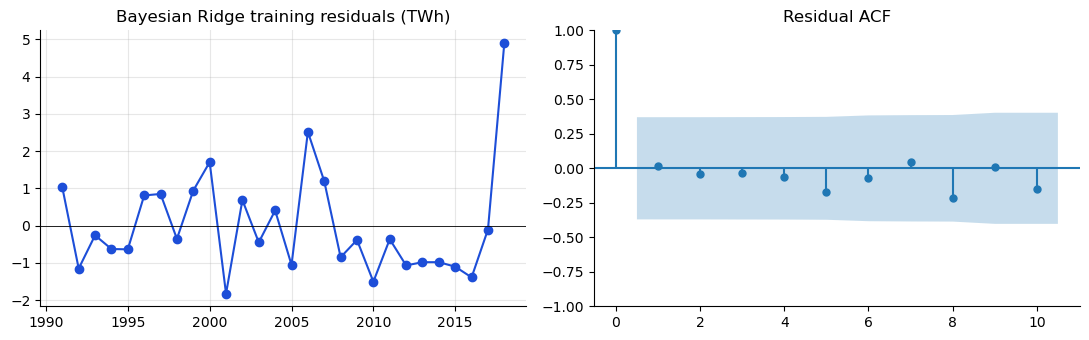

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
res_b = yt_ext - mdl_ext.predict(sc_ext.transform(Xt_ext))
fig, axes = plt.subplots(1,2, figsize=(11,3.5))
axes[0].plot(ytr_ext, res_b, 'o-', color='#1d4ed8'); axes[0].axhline(0, color='black', lw=.6)
axes[0].set_title('Bayesian Ridge training residuals (TWh)'); axes[0].grid(alpha=.3)
plot_acf(res_b, lags=min(10, len(res_b)//2-1), ax=axes[1])
axes[1].set_title('Residual ACF')
plt.tight_layout(); plt.show()


### 9.2 Permutation feature importance on Bayesian Ridge (extended)

                  feature  importance_mean  importance_sd
                cons_lag1           0.8436         0.5787
                    cdd24           0.0595         0.0294
industry_va_const2015_usd           0.0148         0.0539
services_va_const2015_usd           0.0025         0.0271
                    hdd18           0.0003         0.0010
     gdp_pc_const2015_usd          -0.0000         0.0005
         urban_pop_pct_wb          -0.0010         0.0021


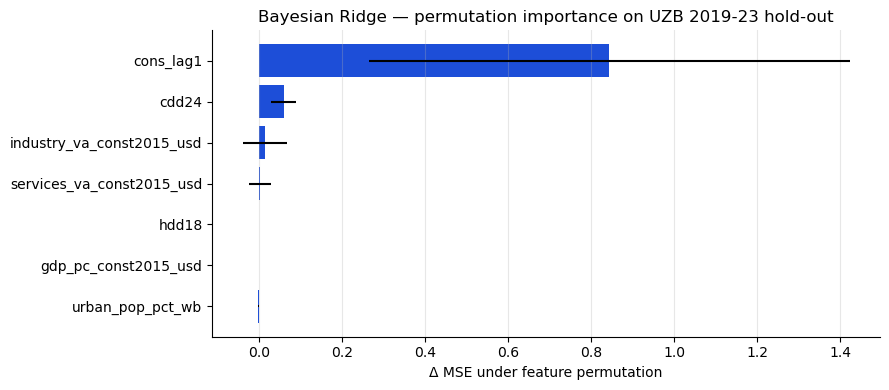

In [21]:
perm = permutation_importance(mdl_ext, sc_ext.transform(Xv_ext), yv_ext,
                              n_repeats=50, random_state=SEED)
imp = pd.DataFrame({'feature': FEATS_EXT,
                    'importance_mean': perm.importances_mean,
                    'importance_sd':   perm.importances_std}).sort_values('importance_mean', ascending=False)
print(imp.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(imp))
ax.barh(y, imp['importance_mean'], xerr=imp['importance_sd'], color='#1d4ed8')
ax.set_yticks(y); ax.set_yticklabels(imp['feature']); ax.invert_yaxis()
ax.set_title('Bayesian Ridge — permutation importance on UZB 2019-23 hold-out')
ax.set_xlabel('Δ MSE under feature permutation'); ax.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()


### 9.3 Pooled-model leave-one-country-out (LOCO) cross-validation

If the pooled model truly learns regional structure (rather than memorising one country), LOCO MAPE should be in the same ballpark as the within-country test MAPE. Sharp degradation means the model leans on one country.


In [22]:
loco_rows = []
COUNTRIES_CA = list(ca['iso_code'].unique())
for held in COUNTRIES_CA:
    tr = ca[(ca['iso_code']!=held) & (ca['year']<=2018)]
    te = ca[(ca['iso_code']==held) & (ca['year']>=2019) & (ca['year']<=2023)]
    if len(te) == 0: continue
    sc_local = StandardScaler().fit(tr[continuous])
    def s(df):
        out = df[FEATS_POOL].copy()
        out[continuous] = sc_local.transform(df[continuous])
        return out.values
    m = Ridge(alpha=alpha_pool, random_state=SEED).fit(s(tr), tr['electricity_demand'])  # reuse the pooled CV-selected penalty
    pred = m.predict(s(te))
    loco_rows.append({'held_out_country': held, 'n_test': len(te),
                      'mape%': mape(te['electricity_demand'], pred),
                      'rmse_twh': rmse(te['electricity_demand'], pred)})
loco = pd.DataFrame(loco_rows).round(3)
print('LOCO pooled Ridge:')
print(loco.to_string(index=False))


LOCO pooled Ridge:
held_out_country  n_test  mape%  rmse_twh
             KAZ       5 23.383    26.099
             KGZ       5 11.672     1.906
             TJK       5  8.108     1.597
             UZB       5 19.645    14.546


## 10. What the maintainer should do next

Limitations explicit so the supervisor sees the honest contour of the work:

1. **Tariff price elasticity not yet identified** — tariff has only two step-changes in the 2017-2024 window. Recommended: dig pre-2017 decrees from lex.uz, then refit BayesianRidge with `residential_uzs_kwh_real` as a feature.
2. **Oblast panel (210 obs) not used in this notebook** — the next step is a separate notebook `08_oblast_demand_panel.ipynb` that fits a hierarchical Bayesian Ridge (or a panel-data GMM) on the oblast × year structure. The data is already cleaned in `data/processed/uzstat_clean/uzb_electricity_oblast.csv`.
3. **Multi-driver ECM vs Prophet gap from 03b** — the 22 % gap between Prophet and the multi-driver model is partially closed in the §3 extended Bayesian Ridge (which is materially closer to Prophet). Document the choice of headline model on the dashboard.

### Artefacts produced
- `data/processed/forecast_demand_bayes_ridge.csv`
- `data/processed/forecast_demand_bayes_ridge.png`
- `data/processed/forecast_demand_bayes_scenarios.csv`
- `data/processed/forecast_demand_bayes_scenarios.png`
- `data/processed/forecast_scoreboard_advanced.csv`

### Citations behind the modelling choices
1. Bayesian Ridge as small-sample energy-demand model — Tipping, M. E. (2001). *Sparse Bayesian learning and the relevance vector machine.* JMLR 1.
2. Pooled cross-country panel for emerging-market electricity demand — IRENA *Pathways to a renewable future*, IEA *Central Asia Energy Outlook 2024*; methodological underpinning: Hsiao, C. (2014). *Analysis of Panel Data* (3rd ed.), Cambridge UP §3.
